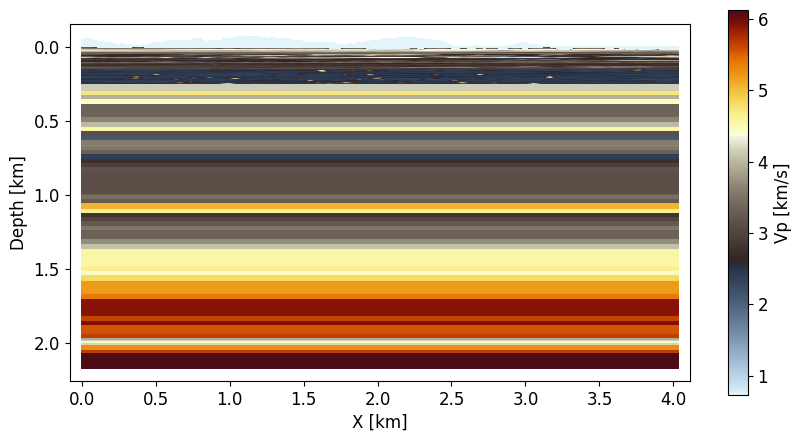

In [1]:
import numpy as np
from frequensolve import *

project_path = "./scratch/ex_03/"

project = Project(
    name = "project",
    pretty_name = "Desert Simulation",
    path = project_path,
    load_if_exists = False
)

sim = SeismicSimulation(
    name = "desert",
    physics = "elastic",
    dimension = 2,
)
project += sim

# --- Model ---
model = LayeredModel(
    dimension = 2, 
    x_limits = [0.0, 4.029],
)

model.add_surface(
    name = "dune_topo",
    z = "desert_data/dune_topo.nc",
    z_ref = 0.0,
)

model.add_layer(
    name = "sand",
    properties = { 
        "Vp" : 0.731, 
        "Vs" : 0.3, 
        "Rho": 1.6,
        "Qp" : 50.0,
        "Qs" : 30.0,
    }
)
                
model.add_surface(
    name = "buried_topo",
    z = "desert_data/buried_topo.nc",
    z_ref = 0.025,
)

model.add_layer(
    name = "near_surface",
    properties = { 
        "Vp" : "desert_data/Vp_near.nc",
        "Vs" : "desert_data/Vs_near.nc",
        "Rho": "desert_data/Rho_near.nc",
        "Qp" : 100.0,
        "Qs" : 50.0,
    }
)

model.add_surface(z = 0.483e-1)
model.add_surface(z = 0.972e-1)
model.add_surface(z = 1.512e-1)
model.add_surface(z = 1.941e-1)
model.add_surface(z = 2.508e-1)

model.add_layer(
    name = "sub_surface",
    properties = { 
        "Vp" : "desert_data/Vp1D.nc",
        "Vs" : "desert_data/Vs1D.nc",
        "Rho": "desert_data/Rho1D.nc",
        "Qp" : 100.0,
        "Qs" : 100.0
    }
)

# Add lower surfaces
z_list = [ 3.9e-1, 4.791e-1, 5.712e-1, 6.312e-1, 6.99e-1, 
          7.551e-1, 9.981e-1, 1.059e0, 1.1211e0, 1.3032e0, 1.3662e0, 
          1.548e0, 1.7052e0, 1.8201e0, 1.881e0, 1.9692e0, 2.016e0,
          2.067e0, 2.1747e0 ]
for z in z_list:
    model.add_surface(z = z)
sim.model = model

model.plot(
    property = "Vp",
    figsize = (10,5),
    aspect = "equal",
    surfaces = False,
    cmap = RdYlBu_r
)

# --- Mesh ---
mesh = model.hex_mesh_generator(n = [4, 4])
sim += mesh
sim.mesh.set_adapt(
    min_epw = 2,
    jump_factor = 2,
    jump_tolerance = 0.1,
)

In [2]:
# --- Boundary Conditions ---

BCs = BoundaryConditionManager(label_type = "geometric")

# Free surface BC
BCs += BoundaryCondition(
    name = "free_surface",
    kind = "neumann",
    boundaries = ["z_min"]
)

# Perfectly matched layer (absorbing boundary condition)
BCs += BoundaryCondition(
    name = "pml",
    kind = "pml",
    boundaries = ["x_min", "x_max", "z_max"],
    pml_wavelengths = 1.3,
    pml_exponent = 3.0,
    pml_constant = 40.0
)
sim += BCs

# --- Acquisition ---

acq = Acquisition()

# Source
acq.add_source_group(
    kind = "vector",
    coords = [[2.0, 0.0]],
    direction = [0.0, 1.0],
    frame = "reference"
)

# Receivers
device = ReceiverNode(name = "geophone")
device.add_component("u_z","displacement",[0.0, 1.0])
device.add_component("u_x","displacement",[1.0, 0.0])

coords = [ [x, 0.0] for x in np.linspace(0.0, 4.0, 1001)]

acq.add_receiver_group(
    name = "surface_geophones",
    device = device,
    coords = coords,
    frame = "reference"
)
sim += acq

# --- Discretization ---

method = Discretization(order = 4)
sim += method

# --- Solver Options ---

solver = SolverConfig(
    solve_on = "final",
    max_iter = 300,
    grids = 4,
    tolerance = 1.0e-4
)
sim += solver

# --- Outputs ---

out = OutputManager()
out += ParaviewOutput(
    name = "desert", 
    fields = ["displacement"], 
    upscale = 1
)
sim += out

project.save()

'/Users/jacobbadger/omnirepo/FrequenSolve/examples/scratch/ex_03/project.json'


  ooooo                                         .oPYo.        8
  8                                             8             8
  8oo   oPYo. .oPYo. .oPYo. o    o .oPYo. odYo. `Yooo. .oPYo. 8 o    o .oPYo.
  8     8  `' 8oooo8 8    8 8    8 8oooo8 8' `8     `8 8    8 8 Y.  .P 8oooo8
  8     8     8.     8    8 8    8 8.     8   8      8 8    8 8 `b..d' 8.
  8     8     `Yooo' `YooP8 `YooP' `Yooo' 8   8 `YooP' `YooP' 8  `YP'  `Yooo'
                          8
                          8


 Copyright (c) 2023-2025 Jacob Badger, FrequenSol LLC -- All Rights Reserved

   This proprietary software is only available to authorized individuals,
   if you encounter this message and do not have a license, please contact
   the copyright holders (Jacob Badger <jacob.badger@frequensol.com>)


 Greetings master.

 -- Parallelism -- 
 Ranks  :    1
 Threads:   16

 -- BCs -- 
 face, BC: 1 Neumann
 face, BC: 2 PML
 face, BC: 3 PML
 face, BC: 4 PML

 -- Hex Mesh -- 
 # elems:       6      26

 recei

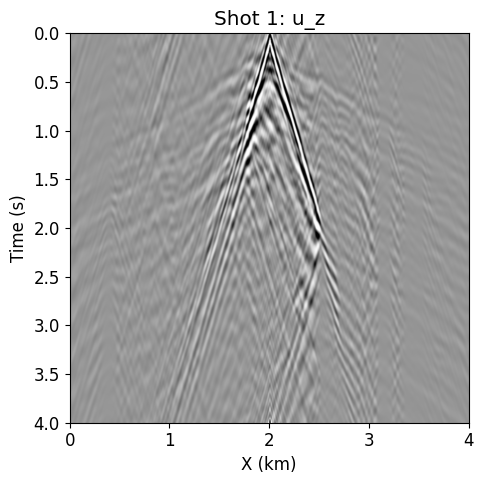

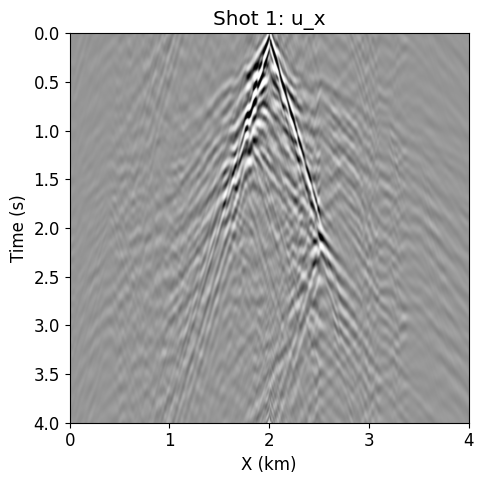

In [3]:
# --- Connect to site ---
   
site = "local"

if site == "local":
    site = LocalSite()
elif site == "stampede3":
    site = Stampede3Site(
        rel_path = "problems/ex_01/",
        default_queue = "skx-dev"
    )
else:
    raise ValueError(f"Site {site} not supported; specify a valid site from options above.")

site.sync(project)

# Create job for time domain simulation
job = TimeDomainJob(
    name = "job",
    simulation = sim,
    f_min = 1.0,
    f_max = 10.0,
    T_max = 4.0
)

if site.provisioned:
    pass
    site.submit(job)
else:
    site.submit_SLURM(
        job = job,
        nodes = 1,
        procs_per_node = 12,
        procs_per_task = 1,
        queue = "skx-dev",
        duration = "00-00:01:00",
    )

    # Wait for SLURM job to complete
    site.wait_completion(job)

# Get results from the site
trace_db = site.fetch_traces(job, upscale = 4)
wavelet = RickerWavelet(
    f0 = 5.0,
    times = trace_db.times(), 
    offset = 5
)

for record in trace_db:
    shot = record.read_TD(wavelet)
    plot_gather(shot, A = 500)
